# Heatmap example

In [1]:
# %%%%%%%% imports
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import plot_misc.utils as pm_utils
import plot_misc.heatmap as heatmap
import plot_misc.example_data.examples as examples
%matplotlib inline
from IPython.core.display import display


In [2]:
# import example data
matrix = examples.load_heatmap_data()

# constants
CMTOINCH = 1/2.54
CBAR_FSIZE=12
CBAR_FTSIZE=8
CBAR_LABEL =  r"dir $\times -\log_{10}$(p)"
LWD = 1.0
PAD=1.5
COLB= 'b'
LENT=3
CMAP_N=13

# CMAP
cmap = plt.get_cmap("PiYG", CMAP_N)
bounds = [-8, -6, -4, -2, 0, 2, 4, 6, 8]
norm = pm_utils.MidpointNormalize(vcenter = 0, vmin=-8, vmax=8)

## plotting heatmap
Adding additional annotations.

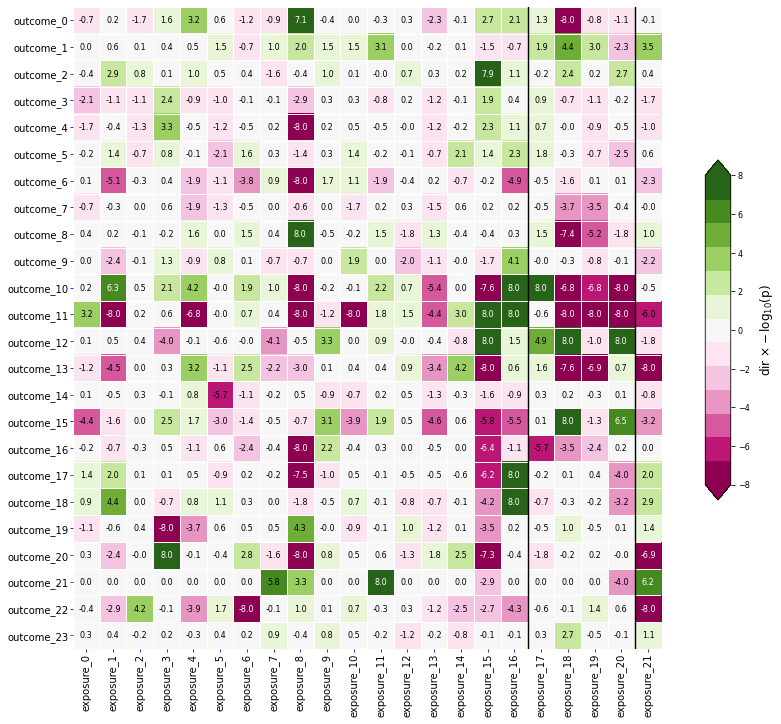

In [4]:
fig, ax = plt.subplots(1, figsize=(30*CMTOINCH, 30*CMTOINCH))
# location of cbar
cbar_ax = fig.add_axes([.91, .3, .03, .4])
# plotting heatmap
im, cbar = heatmap.heatmap(data=matrix, row_labels=matrix.index.to_list(),
                           col_labels=matrix.columns.to_list(), ax=ax,
                           cmap=cmap,grid_linewidth=LWD,
                           )
# adding annotation
texts = heatmap.annotate_heatmap(im, threshold=6, valfmt="{x:.1f}", fontsize=8)

# adding cbar
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
             cax=cbar_ax, orientation='vertical', extend='both',
             )
# cbar formatting
cbar_ax.axes.set_ylabel(CBAR_LABEL, fontsize=CBAR_FSIZE, rotation=90, labelpad=8)
cbar_ax.axes.set_yticklabels(cbar_ax.axes.get_ymajorticklabels(),
                           fontsize=CBAR_FTSIZE)
# ticks
im.axes.tick_params(pad=PAD, color=COLB, length=LENT, bottom=True)
im.axes.set_xticklabels(im.axes.get_xmajorticklabels(), fontsize=10,
                        rotation=90, va='center')
# hline
im.axes.axvline(16.5, linewidth=1.4, color='black')
im.axes.axvline(20.5, linewidth=1.4, color='black')